### 🔄 AdaBoost vs Gradient Boosting: Key Differences

**No, AdaBoost is NOT Gradient Boosting with `n_estimator=1`!** They are fundamentally different algorithms:

#### **Similarities:**
- Both are **boosting algorithms** (sequential ensemble methods)
- Both combine **weak learners** (usually decision trees)
- Both build models **sequentially**
- Both focus on **correcting previous mistakes**

#### **Key Differences:**

| Aspect | AdaBoost | Gradient Boosting |
|--------|----------|-------------------|
| **Loss Function** | Exponential loss: `exp(-y·f(x))` | Various losses (deviance, exponential, etc.) |
| **Weighting Strategy** | **Sample weights** - increases weight of misclassified samples | **Tree weights** - weights the contribution of each tree |
| **Focus** | Hard-to-classify **samples** | **Residuals** (errors) of previous model |
| **Learning Rate** | Built into sample weights | Separate `learning_rate` parameter |
| **Base Learner** | Usually **stumps** (depth=1) | Usually **deeper trees** (depth=3-6) |
| **Error Correction** | Re-weights training samples | Fits residuals directly |
| **Mathematical Approach** | Minimizes exponential loss | Gradient descent on loss function |

#### **How AdaBoost Works:**
1. Start with equal weights for all samples
2. Train a weak learner (usually depth=1 tree)
3. Calculate error rate
4. **Increase weights** of misclassified samples
5. Train next learner on **re-weighted samples**
6. Combine all learners with weighted voting

#### **How Gradient Boosting Works:**
1. Start with initial prediction (mean/log-odds)
2. Calculate **residuals** (errors)
3. Train a tree to **predict residuals**
4. Add tree to ensemble with learning rate
5. Update predictions
6. Repeat until convergence

#### **When to Use AdaBoost:**
- Binary classification problems
- When you want simple, interpretable models
- When base learners are very weak (stumps)
- Faster training than Gradient Boosting

#### **When to Use Gradient Boosting:**
- Both classification and regression
- When you need higher accuracy
- When you can use deeper trees
- More flexible loss functions

#### **Summary:**
- **AdaBoost**: Focuses on **hard samples** by re-weighting them
- **Gradient Boosting**: Focuses on **residuals** by fitting them directly
- Both are boosting, but use different strategies!

# 🚀 Gradient Boosting - Crop Recommendation

## Overview
Gradient Boosting is a **powerful ensemble learning technique** that builds models sequentially, where each new model (typically a weak learner like a decision tree) corrects the errors made by the previous models. It's one of the most effective machine learning algorithms for structured data.

### Key Concepts:
- **Boosting**: Sequentially combines weak learners into a strong learner
- **Gradient Descent**: Minimizes loss function by following the negative gradient
- **Sequential Learning**: Each model learns from the mistakes of previous models
- **Residual Fitting**: New models fit the residuals (errors) of previous models

### How Gradient Boosting Works:
1. **Initialize**: Start with a simple model (usually mean/median for regression, log-odds for classification)
2. **Iterate**: For each iteration:
   - Calculate residuals (errors) from current model
   - Fit a new weak learner (tree) to predict these residuals
   - Add the new model to the ensemble with a learning rate
   - Update predictions
3. **Final Model**: Sum of all weak learners

### Mathematical Foundation:
- **Loss Function**: Measures prediction error (e.g., log-loss for classification)
- **Gradient**: Direction of steepest increase in loss
- **Negative Gradient**: Direction to reduce loss (what we want to predict)
- **Learning Rate (α)**: Controls contribution of each tree (shrinkage)

### Key Hyperparameters:
- **n_estimators**: Number of boosting stages (trees)
- **learning_rate**: Shrinkage factor (0.01 to 0.3 typical)
- **max_depth**: Maximum depth of individual trees
- **min_samples_split**: Minimum samples required to split a node
- **min_samples_leaf**: Minimum samples in a leaf node
- **subsample**: Fraction of samples used for each tree (stochastic gradient boosting)
- **max_features**: Number of features to consider for best split

### Advantages:
- Very high predictive accuracy
- Handles non-linear relationships well
- Provides feature importance
- Works well with mixed data types
- Robust to outliers (with proper tuning)

### Disadvantages:
- Can overfit if not properly tuned
- Slower training than Random Forest
- Requires careful hyperparameter tuning
- Less interpretable than single trees
- Sensitive to noisy data

## 1. Imports and Setup

In [1]:
!pip install scikit-learn numpy pandas matplotlib seaborn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [2]:
# =============================================================================
# 1. IMPORTS
# =============================================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    cross_validate,
    learning_curve,
    validation_curve
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

## 2. Data Loading and Exploration

In [3]:
# =============================================================================
# 2. DATA LOADING
# =============================================================================

data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
df = pd.read_csv(data_url)

## 3. Data Preprocessing

In [6]:
# =============================================================================
# 4. FEATURE PREPARATION
# =============================================================================

# Separate features and target
feature_col = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[feature_col]
y = df['crop']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Features: {X_train.shape[1]}")

# Note: Gradient Boosting doesn't require feature scaling
# but it can help with numerical stability

  Training set: 1320 samples
  Test set: 330 samples
  Features: 7


## 4. Baseline Gradient Boosting Model

In [8]:
# =============================================================================
# 5. BASELINE GRADIENT BOOSTING MODEL
# =============================================================================

# Create baseline Gradient Boosting with default parameters
gb_baseline = GradientBoostingClassifier(
    n_estimators=100,      # Number of boosting stages
    learning_rate=0.1,     # Shrinkage factor
    max_depth=3,           # Maximum depth of trees
    random_state=42        # For reproducibility
)

# Train the model
gb_baseline.fit(X_train, y_train)

# Predictions
y_pred_baseline = gb_baseline.predict(X_test)

# Evaluate
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, average='weighted')
recall_baseline = recall_score(y_test, y_pred_baseline, average='weighted')
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print(f"   Accuracy:  {accuracy_baseline:.4f} ({accuracy_baseline*100:.2f}%)")
print(f"   Precision: {precision_baseline:.4f}")
print(f"   Recall:    {recall_baseline:.4f}")
print(f"   F1-Score:  {f1_baseline:.4f}")


   Accuracy:  0.9848 (98.48%)
   Precision: 0.9858
   Recall:    0.9848
   F1-Score:  0.9849


### 📚 Gradient Boosting Parameters Explanation

#### **`n_estimators=100`** (Number of Trees)
- **Purpose**: Number of boosting stages (trees) to build
- **Low (e.g., 50)**: Faster training, may underfit
- **High (e.g., 500)**: Better fit, but slower and risk of overfitting
- **Trade-off**: More trees = better performance but diminishing returns
- **With early stopping**: Can train many trees and stop when validation doesn't improve

#### **`learning_rate=0.1`** (Shrinkage)
- **Purpose**: Controls contribution of each tree (step size)
- **Low (e.g., 0.01)**: Smaller steps, need more trees, more stable
- **High (e.g., 0.3)**: Larger steps, fewer trees needed, faster but less stable
- **Rule of thumb**: `learning_rate × n_estimators` should be constant
- **Typical range**: 0.01 to 0.3

#### **`max_depth=3`** (Tree Depth)
- **Purpose**: Maximum depth of individual trees
- **Low (1-3)**: Simpler trees, less overfitting, faster
- **High (5-10)**: More complex trees, captures interactions, risk of overfitting
- **Typical**: 3-6 for most problems

#### **`min_samples_split`** (Default: 2)
- **Purpose**: Minimum samples required to split a node
- **Low**: More splits, more complex trees
- **High**: Fewer splits, simpler trees, less overfitting

#### **`min_samples_leaf`** (Default: 1)
- **Purpose**: Minimum samples in a leaf node
- **Low**: More leaves, more complex
- **High**: Fewer leaves, simpler, smoother predictions

#### **`subsample`** (Default: 1.0)
- **Purpose**: Fraction of samples used for each tree
- **1.0**: Use all samples (standard gradient boosting)
- **< 1.0**: Stochastic gradient boosting (e.g., 0.8)
- **Benefits**: Reduces overfitting, adds randomness

#### **`max_features`** (Default: None = all features)
- **Purpose**: Number of features to consider for best split
- **'sqrt'**: sqrt(n_features)
- **'log2'**: log2(n_features)
- **Float**: Fraction of features
- **Benefits**: Adds randomness, reduces overfitting

## 5. Early Stopping (Preventing Overfitting)

In [9]:

# Create model with early stopping
gb_early_stop = GradientBoostingClassifier(
    n_estimators=500,           # Train up to 500 trees
    learning_rate=0.1,
    max_depth=3,
    validation_fraction=0.2,   # Fraction of training data for validation
    n_iter_no_change=10,       # Stop if no improvement for 10 iterations
    tol=1e-4,                  # Tolerance for early stopping
    random_state=42
)

# Train with early stopping
gb_early_stop.fit(X_train, y_train)

# Check how many trees were actually used
n_trees_used = gb_early_stop.n_estimators_
print(f"\n✅ Trees trained: {n_trees_used} (out of 500 max)")

# Evaluate
y_pred_early = gb_early_stop.predict(X_test)
accuracy_early = accuracy_score(y_test, y_pred_early)

print(f"\n📊 Early Stopping Results:")
print(f"   Accuracy: {accuracy_early:.4f} ({accuracy_early*100:.2f}%)")
print(f"   Trees used: {n_trees_used}")



✅ Trees trained: 49 (out of 500 max)

📊 Early Stopping Results:
   Accuracy: 0.9848 (98.48%)
   Trees used: 49


## 6. Hyperparameter Tuning with GridSearchCV

In [12]:

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
}

# Create GridSearchCV
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
✅ Best CV Score: 0.9826


## 7. Final Model Evaluation

In [13]:
# Get best model from GridSearchCV
gb_final = grid_search.best_estimator_

# Make predictions on test set
y_pred_final = gb_final.predict(X_test)

# Calculate metrics
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print(f"\n📊 Final Model Results:")
print(f"   Accuracy:  {accuracy_final:.4f} ({accuracy_final*100:.2f}%)")
print(f"   Precision: {precision_final:.4f}")
print(f"   Recall:    {recall_final:.4f}")
print(f"   F1-Score:  {f1_final:.4f}")

# Compare with baseline
print(f"\n📈 Comparison with Baseline:")
print(f"   Baseline Accuracy: {accuracy_baseline:.4f}")
print(f"   Final Accuracy:    {accuracy_final:.4f}")
print(f"   Improvement:      {accuracy_final - accuracy_baseline:.4f} ({(accuracy_final - accuracy_baseline)*100:.2f}%)")



📊 Final Model Results:
   Accuracy:  0.9879 (98.79%)
   Precision: 0.9890
   Recall:    0.9879
   F1-Score:  0.9876

📈 Comparison with Baseline:
   Baseline Accuracy: 0.9848
   Final Accuracy:    0.9879
   Improvement:      0.0030 (0.30%)


In [14]:
# =============================================================================
# 9. DETAILED CLASSIFICATION REPORT
# =============================================================================

print("📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

📋 Detailed Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      0.80      0.89        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       0.88      1.00      0.94        15
      grapes       1.00      1.00      1.00        15
        jute       1.00      1.00      1.00        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      0.93      0.97        15
       mango       1.00      1.00      1.00        15
   mothbeans       0.94      1.00      0.97        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.00    

<Figure size 1400x1200 with 0 Axes>

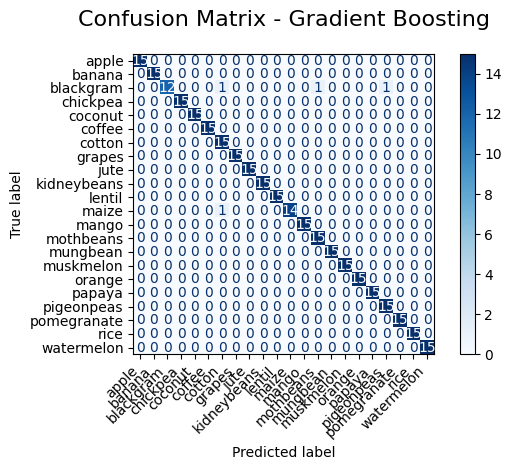

In [15]:
# =============================================================================
# 10. CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, y_pred_final)

# Visualize confusion matrix
plt.figure(figsize=(14, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Gradient Boosting', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
import joblib
from pathlib import Path

model_obj = None
for name in ["best_gb", "grid_search", "gb_early_stop", "gb_baseline", "model"]:
    if name in globals():
        candidate = globals()[name]
        model_obj = getattr(candidate, "best_estimator_", candidate)
        break

if model_obj is None:
    raise ValueError("No trained model variable found in notebook globals.")

output_path = Path("../../models/gradient_boosting.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")

## Quick inference test

Use the next cell to test the trained model on your own input values.

In [ ]:
# INFERENCE_TEST_SAMPLE
import pandas as pd
import numpy as np

# Update these values to test custom input
sample_input = {
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 20.9,
    "humidity": 82.0,
    "ph": 6.5,
    "rainfall": 202.9,
}

feature_order = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
input_df = pd.DataFrame([sample_input])[feature_order]

model_candidates = [
    "knn_final", "gb_final", "dt_model", "model", "nb_baseline", "svm_baseline", "knn_cls", "gs", "grid_search"
]
model_obj = next((globals().get(name) for name in model_candidates if globals().get(name) is not None), None)

if model_obj is None:
    raise NameError(f"No trained model found. Checked: {model_candidates}")

if hasattr(model_obj, "best_estimator_"):
    model_obj = model_obj.best_estimator_

scaler_obj = globals().get("scaler")
if scaler_obj is not None:
    scaled_values = scaler_obj.transform(input_df)
    if "X_train_scaler_df" in globals():
        input_for_model = pd.DataFrame(scaled_values, columns=feature_order)
    else:
        input_for_model = scaled_values
else:
    input_for_model = input_df

raw_prediction = model_obj.predict(input_for_model)[0]
encoder_obj = globals().get("le") or globals().get("label_encoder")

if encoder_obj is not None:
    try:
        predicted_crop = encoder_obj.inverse_transform([int(raw_prediction)])[0]
    except Exception:
        predicted_crop = str(raw_prediction)
else:
    predicted_crop = str(raw_prediction)

print("Input sample:")
print(input_df)
print(f"\nPredicted crop: {predicted_crop}")

if hasattr(model_obj, "predict_proba"):
    probabilities = model_obj.predict_proba(input_for_model)[0]
    top_indices = np.argsort(probabilities)[-3:][::-1]

    if encoder_obj is not None and hasattr(encoder_obj, "classes_"):
        top_labels = [encoder_obj.classes_[idx] for idx in top_indices]
    else:
        top_labels = [str(idx) for idx in top_indices]

    print("\nTop 3 class probabilities:")
    for label, idx in zip(top_labels, top_indices):
        print(f"- {label}: {probabilities[idx]:.4f}")

